In [7]:
import requests
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import gc
from torch.utils.data import DataLoader

# Prediction Model Setup

In [2]:
# ------------------------------------------------------------------
# AI MODEL CONFIGURATION
# ------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

model_registry = {
    "Atelectasis": "/home/varrel/image_model_dict/final/fixed_swinb_atelectasis_model_epoch6.pth",
    "Cardiomegaly": "/home/varrel/image_model_dict/final/fixed_swinb_cardiomegaly_model_epoch5.pth",
    "Consolidation": "/home/varrel/image_model_dict/final/fixed_swinb_consolidation_model_epoch4.pth",
    "Edema": "/home/varrel/image_model_dict/final/fixed_swinb_edema_model_epoch4.pth",
    "Enlarged Cardiomediastinum": "/home/varrel/image_model_dict/final/fixed_swinb_enlarged_model_epoch7.pth",
    "Fracture": "/home/varrel/image_model_dict/final/fixed_swinb_fracture_model_epoch1.pth",
    "Lung Lesion": "/home/varrel/image_model_dict/final/fixed_swinb_lesion_model_epoch3.pth",
    "Lung Opacity": "/home/varrel/image_model_dict/final/fixed_swinb_opacity_model_epoch7.pth",
    "Pleural Effusion": "/home/varrel/image_model_dict/final/fixed_swinb_effusion_model_epoch5.pth",
    "Pneumonia": "/home/varrel/image_model_dict/final/fixed_swinb_pneumonia_model_epoch2.pth",
    "Pneumothorax": "/home/varrel/image_model_dict/final/fixed_swinb_pneumothorax_model_epoch9.pth",
    "Support Device": "/home/varrel/image_model_dict/final/fixed_swinb_supportdevice_model_epoch6.pth"
}

In [3]:
# ------------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------------
def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    imgs, labs, idxs = [], [], []
    for b in batch:
        img = torch.tensor(b["img"])
        lab = torch.tensor(b["lab"])
        # Ensure 3-channel
        if img.ndim == 3 and img.shape[0] == 1: img = img.repeat(3, 1, 1)
        elif img.ndim == 2: img = img.unsqueeze(0).repeat(3, 1, 1)
        imgs.append(img)
        labs.append(lab)
        idxs.append(b["idx"])
    return {"img": torch.stack(imgs), "lab": torch.stack(labs), "idx": idxs}

def run_inference(model, loader):
    all_probs = []
    all_preds = []
    all_labels = []

    model.eval() # Ensure eval mode is on
    
    with torch.no_grad():
        # Removed tqdm for single-image speed, add it back if processing huge datasets
        for batch in loader: 
            inputs = batch["img"].to(device)
            # Handle labels if they exist, otherwise just fill 0 (for pure inference)
            if "lab" in batch:
                labels = batch["lab"].cpu().numpy()
                labels = np.nan_to_num(labels, nan=0.0).astype(int)
            else:
                labels = np.zeros(len(inputs)) # Dummy labels

            outputs = model(inputs).squeeze(1)
            outputs = torch.clamp(outputs, min=-20, max=20)
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_probs, all_preds, all_labels


def load_single_model(model_path):
    """Loads a single Swin-B model architecture and weights."""
    weights = models.Swin_B_Weights.IMAGENET1K_V1
    model = models.swin_b(weights=weights)
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, 1)
    
    # Load weights
    checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
    
    # Handle state_dict keys (sometimes they have 'module.' prefix)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    
    model.to(device)
    model.eval()
    return model

def run_sequential_inference(loader, model_registry):
    """
    Runs your inference function 12 times (once per pathology).
    Returns a dictionary: { 'Atelectasis': [prob_img1, prob_img2...], ... }
    """
    aggregated_results = {}
    
    print(f"Starting sequential inference on {len(loader.dataset)} image(s)...")

    for pathology, path in model_registry.items():
        print(f"-> Loading {pathology}...", end=" ")
        
        # A. Load
        model = load_single_model(path)
        
        # B. Run YOUR inference function
        probs, _, _ = run_inference(model, loader)
        
        # C. Store Results
        aggregated_results[pathology] = probs
        print(f"Done. (Max Prob: {probs.max():.4f})")
        
        # D. Unload to save memory
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return aggregated_results

# Data & Image Loader

### Label & Image Load

In [16]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from util.PNGDatasetNormalized import PNGFolderDataset

pc_png_selection = PNGFolderDataset(
    img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv", id_col="ImageID")

sample = pc_png_selection[21]
inference_loader = DataLoader([sample], batch_size=1, shuffle=False, collate_fn=safe_collate)

In [17]:
# Real Label
print(pc_png_selection.pathologies)
print(sample["lab"])

['No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardio.', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']
[0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1.]


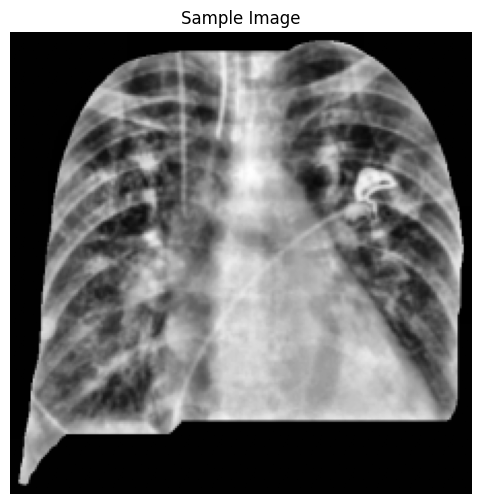

In [18]:
# Real Image
img_data = sample["img"]
if hasattr(img_data, 'numpy'):
    img_data = img_data.numpy()
if img_data.ndim == 3 and img_data.shape[0] == 1:
    img_data = img_data.squeeze(0)

plt.figure(figsize=(6, 6))
plt.imshow(img_data, cmap='gray')
plt.title(f"Sample Image")
plt.axis('off')
plt.show()

### Model Prediction

In [19]:
results_dict = run_sequential_inference(inference_loader, model_registry)
    
print("\n--- SwinB Output (Input for LLM) ---")
llm_input = {k: v[0] for k, v in results_dict.items()}
for k, v in llm_input.items():
    print(f"'{k}': {v:.4f}")

Starting sequential inference on 1 image(s)...
-> Loading Atelectasis... Done. (Max Prob: 0.2162)
-> Loading Cardiomegaly... Done. (Max Prob: 0.3531)
-> Loading Consolidation... Done. (Max Prob: 0.1408)
-> Loading Edema... Done. (Max Prob: 0.1229)
-> Loading Enlarged Cardiomediastinum... Done. (Max Prob: 0.0233)
-> Loading Fracture... Done. (Max Prob: 0.0537)
-> Loading Lung Lesion... Done. (Max Prob: 0.0059)
-> Loading Lung Opacity... Done. (Max Prob: 0.7807)
-> Loading Pleural Effusion... Done. (Max Prob: 0.9117)
-> Loading Pneumonia... Done. (Max Prob: 0.1722)
-> Loading Pneumothorax... Done. (Max Prob: 0.0224)
-> Loading Support Device... Done. (Max Prob: 0.9318)

--- SwinB Output (Input for LLM) ---
'Atelectasis': 0.2162
'Cardiomegaly': 0.3531
'Consolidation': 0.1408
'Edema': 0.1229
'Enlarged Cardiomediastinum': 0.0233
'Fracture': 0.0537
'Lung Lesion': 0.0059
'Lung Opacity': 0.7807
'Pleural Effusion': 0.9117
'Pneumonia': 0.1722
'Pneumothorax': 0.0224
'Support Device': 0.9318


# Report Generation

In [21]:
my_model = "gpt-oss:20b"
formatted_scores = "\n".join([f"- {k}: {v[0]:.4f}" for k, v in results_dict.items()])
print("--- Input Scores ---")
print(formatted_scores)

# ------------------------------------------------------------------
# PROMPTING
# ------------------------------------------------------------------
system_prompt = (
    "You are a board-certified radiologist assistant. "
    "Your task is to draft the 'IMPRESSION' section of a chest X-ray report "
    "based strictly on the provided pathology probability scores."
)

user_prompt = f"""
Here are the probability scores generated by a deep learning model for 12 chest pathologies:

{formatted_scores}

Instructions:
1. **Analyze Findings:**
   - **Score > 0.7 (Positive):** Report as consistent with the pathology.
   - **Score 0.2 - 0.7 (Uncertain):** Report as "cannot be excluded" or "possible".
   - **Score < 0.2 (Negative):** Report as no evidence.

2. **Writing Style:**
   - Synthesize the findings into a **single, professional paragraph**.
   - **Important:** If multiple pathologies are negative (Score < 0.2), group them into a single sentence (e.g., "No evidence of pneumothorax, edema, or mass.") rather than listing them one by one.
   - Start with the most critical positive findings.
   - Use standard radiological terminology.

3. **Output:** - Provide ONLY the text for the 'IMPRESSION' section. 
   - Do not use markdown headers or conversational filler.
"""

# ------------------------------------------------------------------
# 3. INFERENCE
# ------------------------------------------------------------------
try:
    final_first_response_gpt = requests.post(
        'http://127.0.0.1:11434/api/chat',
        json={
            "model": my_model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            "stream": False,
            "seed": 42,
            "temperature": 0.2,
            "top_p": 0.9,
            "num_predict": 512
        }
    )
    
    # Check if request was successful
    if final_first_response_gpt.status_code == 200:
        print("\n--- Generated Report ---")
        print(final_first_response_gpt.json()['message']['content'])
    else:
        print(f"Error: {final_first_response_gpt.status_code} - {final_first_response_gpt.text}")

except Exception as e:
    print(f"Connection failed: {e}")

--- Input Scores ---
- Atelectasis: 0.2162
- Cardiomegaly: 0.3531
- Consolidation: 0.1408
- Edema: 0.1229
- Enlarged Cardiomediastinum: 0.0233
- Fracture: 0.0537
- Lung Lesion: 0.0059
- Lung Opacity: 0.7807
- Pleural Effusion: 0.9117
- Pneumonia: 0.1722
- Pneumothorax: 0.0224
- Support Device: 0.9318

--- Generated Report ---
Support device in place; large bilateral pleural effusion is evident, with dense lung opacity consistent with effusion and possible dependent atelectasis. Atelectasis and cardiomegaly cannot be excluded. No evidence of consolidation, edema, enlarged cardiomediastinum, fracture, lung lesion, pneumonia, or pneumothorax.
